# Algoritmi numerici, errori e aritmetica floating-point

Questo capitolo tratta: 

- algoritmi numerici, errori e proprietà degli algoritmi;
- errori di arrotondamento e sistemi floating-point.

L'obiettivo della lezione è costruire una comprensione operativa dei concetti fondamentali del calcolo scientifico:

1. perché i calcoli numerici sono inevitabilmente approssimati;
2. come misurare errore assoluto ed errore relativo;
3. quali errori derivano da modello, discretizzazione, convergenza e arrotondamento;
4. come si comportano gli errori di discretizzazione nella differenziazione numerica;
5. perché ridurre il passo $h$ non migliora sempre il risultato;
6. cosa sono accuratezza, efficienza e robustezza;
7. differenza fra condizionamento del problema e stabilità dell'algoritmo;
8. come funziona una rappresentazione floating-point;
9. cosa sono unità di arrotondamento, overflow, underflow, NaN e cancellazione;
10. come progettare formule numericamente più stabili.


In [1473]:
import math
import struct
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=16, suppress=False)

# Parte I — Calcolo scientifico e algoritmi numerici

## 1. Che cos'è il calcolo scientifico

Il calcolo scientifico studia lo sviluppo e l'analisi di algoritmi numerici per risolvere problemi matematici che nascono da modelli scientifici, ingegneristici e informatici.

Uno schema concettuale tipico è:

$$
\text{fenomeno osservato}
\rightarrow
\text{modello matematico}
\rightarrow
\text{discretizzazione}
\rightarrow
\text{algoritmo di soluzione}
\rightarrow
\text{implementazione}.
$$

Il punto centrale è che il problema matematico originario è spesso continuo, mentre il computer può manipolare solo oggetti finiti.

Per esempio:

- una funzione continua viene sostituita da un array di valori;
- una derivata viene sostituita da una formula alle differenze finite;
- un integrale viene sostituito da una somma;
- un'equazione differenziale viene sostituita da un sistema algebrico.

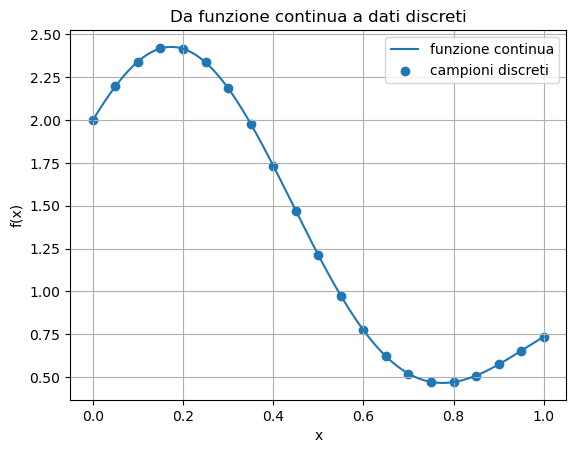

In [1474]:
# Esempio: una funzione continua campionata su una griglia finita.

def f_continua(x):
    return np.exp(-x) * (np.sin(2*np.pi*x) + 2)

x_fine = np.linspace(0, 1, 600)
x_grid = np.linspace(0, 1, 21)

plt.figure()
plt.plot(x_fine, f_continua(x_fine), label="funzione continua")
plt.scatter(x_grid, f_continua(x_grid), label="campioni discreti")
plt.title("Da funzione continua a dati discreti")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True)
plt.legend()
plt.show()

## 2. Calcolo scientifico e analisi numerica

È utile distinguere due livelli.

**Calcolo scientifico:** comprende l'intero processo: modello, discretizzazione, algoritmo, implementazione, strutture dati, architettura di calcolo e interpretazione dei risultati.

**Analisi numerica:** studia la teoria degli algoritmi numerici: errore, convergenza, stabilità, condizionamento, accuratezza ed efficienza.

In questo notebook lavoriamo soprattutto sugli strumenti di base dell'analisi numerica.

## 3. Perché l'errore è inevitabile

Il risultato di un calcolo numerico interessante è quasi sempre approssimato.

Le cause principali sono:

1. **errore nel modello o nei dati**;
2. **errore di discretizzazione**;
3. **errore di convergenza**;
4. **errore di arrotondamento**.

L'obiettivo non è eliminare completamente l'errore, ma controllarlo e mantenerlo entro una soglia accettabile.

# Parte II — Misurare l'errore

## 4. Errore assoluto

Sia $u$ una quantità esatta e sia $v$ una sua approssimazione.

L'errore assoluto è

$$
|u-v|.
$$

Misura la distanza diretta fra valore esatto e valore approssimato.

È utile quando la scala del problema è nota o quando il valore esatto può essere vicino a zero.

## 5. Errore relativo

Se $u\neq 0$, l'errore relativo è

$$
\frac{|u-v|}{|u|}.
$$

Misura l'errore rispetto alla scala del valore esatto.

L'errore relativo è spesso più informativo dell'errore assoluto, soprattutto quando i valori possono avere grandezze molto diverse.

In [1475]:
examples = [
    (1.0, 0.99),
    (1.0, 1.01),
    (-1.5, -1.2),
    (100.0, 99.99),
    (100.0, 99.0),
    (1e8, 1e8 - 1),
    (1e-8, 2e-8),
]

print(f"{'u esatto':>14} {'v appross.':>14} {'err. assoluto':>16} {'err. relativo':>16}")
for u, v in examples:
    abs_err = abs(u - v)
    rel_err = abs_err / abs(u) if u != 0 else np.nan
    print(f"{u:14.6g} {v:14.6g} {abs_err:16.6g} {rel_err:16.6g}")

      u esatto     v appross.    err. assoluto    err. relativo
             1           0.99             0.01             0.01
             1           1.01             0.01             0.01
          -1.5           -1.2              0.3              0.2
           100          99.99             0.01           0.0001
           100             99                1             0.01
         1e+08          1e+08                1            1e-08
         1e-08          2e-08            1e-08                1


## 6. Quando l'errore relativo è delicato

Se $|u|$ è molto piccolo, l'errore relativo può diventare molto grande o poco significativo.

Per questo motivo, in molti algoritmi si usano criteri misti, per esempio:

$$
|u-v|\le \mathrm{atol}+\mathrm{rtol}|u|.
$$

Qui:

- `atol` è una tolleranza assoluta;
- `rtol` è una tolleranza relativa.

In [1476]:
def errore_misto(u, v, atol=1e-12, rtol=1e-12):
    return abs(u - v) <= atol + rtol * abs(u)

tests = [
    (1.0, 1.0 + 1e-13),
    (1e8, 1e8 + 1e-3),
    (1e-14, 0.0),
]

for u, v in tests:
    print("u =", u, "v =", v, "vicini?", errore_misto(u, v))

u = 1.0 v = 1.0000000000001 vicini? True
u = 100000000.0 v = 100000000.001 vicini? False
u = 1e-14 v = 0.0 vicini? True


# Parte III — Esempio: approssimazione di Stirling

## 7. Formula di Stirling

La formula di Stirling approssima il fattoriale:

$$
n! = 1\cdot 2\cdots n.
$$

L'approssimazione è

$$
S_n=\sqrt{2\pi n}\left(\frac{n}{e}\right)^n.
$$

Questa formula è molto utile perché il fattoriale cresce estremamente velocemente e, per valori grandi di $n$, il calcolo diretto di $n!$ può diventare numericamente problematico.

È un esempio utile perché:

- $n!$ cresce molto velocemente;
- l'errore assoluto cresce;
- l'errore relativo diminuisce.

Quindi l'errore relativo descrive meglio la qualità dell'approssimazione.

In [1477]:
def stirling(n):
    n = np.asarray(n, dtype=float)
    return np.sqrt(2*np.pi*n) * (n/np.e)**n

n = np.arange(1, 16)
fact_n = np.array([math.factorial(int(k)) for k in n], dtype=float)
Sn = stirling(n)

abs_err = np.abs(Sn - fact_n)
rel_err = abs_err / fact_n

print(f"{'n':>3} {'n!':>16} {'S_n':>16} {'Eabs':>16} {'Erel':>16}")
for row in zip(n, fact_n, Sn, abs_err, rel_err):
    print(f"{int(row[0]):3d} {row[1]:16.6g} {row[2]:16.6g} {row[3]:16.6g} {row[4]:16.6g}")

  n               n!              S_n             Eabs             Erel
  1                1         0.922137         0.077863         0.077863
  2                2            1.919        0.0809956        0.0404978
  3                6          5.83621          0.16379        0.0272984
  4               24          23.5062         0.493825         0.020576
  5              120          118.019          1.98083        0.0165069
  6              720          710.078          9.92182        0.0137803
  7             5040           4980.4          59.6042        0.0118262
  8            40320          39902.4          417.605        0.0103573
  9           362880           359537          3343.13       0.00921276
 10       3.6288e+06       3.5987e+06          30104.4       0.00829596
 11      3.99168e+07      3.96156e+07           301175       0.00754507
 12      4.79002e+08      4.75687e+08      3.31411e+06       0.00691879
 13      6.22702e+09      6.18724e+09      3.97813e+07        0.

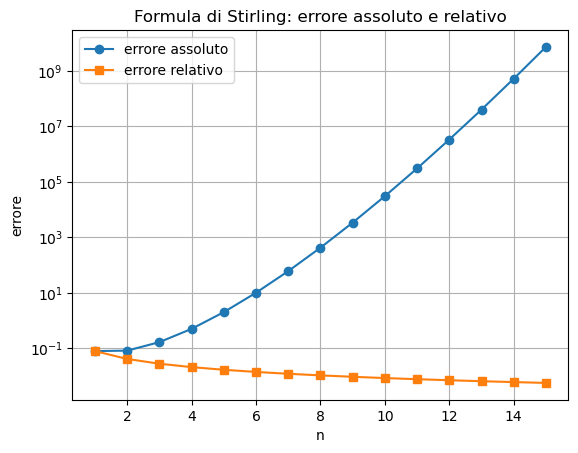

In [1478]:
plt.figure()
plt.semilogy(n, abs_err, marker="o", label="errore assoluto")
plt.semilogy(n, rel_err, marker="s", label="errore relativo")
plt.title("Formula di Stirling: errore assoluto e relativo")
plt.xlabel("n")
plt.ylabel("errore")
plt.grid(True)
plt.legend()
plt.show()

# Parte IV — Tipi di errore

## 8. Errori nel problema

Gli errori nel problema derivano dal modello o dai dati. Non dipendono ancora dall'algoritmo numerico scelto: sono già presenti nella formulazione del problema.

Esempi:

- **Misure sperimentali imprecise.**  
  Se vogliamo stimare la velocità media di un veicolo a partire da misure di spazio e tempo, piccoli errori nel cronometro o nel sensore di posizione producono dati iniziali non esatti. Anche un algoritmo perfetto lavorerebbe quindi su valori già affetti da errore.

- **Fenomeni fisici trascurati.**  
  Nel modellare o spazio percorso verticalmente da un corpo in caduta libera, partendo da fermo, possiamo usare la formula semplificata

  $$
  s(t)=\frac12gt^2,
  $$

  che trascura la resistenza dell'aria. Il modello è semplice e utile, ma non descrive esattamente il fenomeno reale.

- **Semplificazioni geometriche.**  
  In un modello di traffico o logistica, una strada può essere rappresentata come un segmento rettilineo, anche se nella realtà è curva. Questa semplificazione rende il problema più facile da trattare, ma introduce una differenza tra il modello e la situazione reale.

- **Parametri incerti.**  
  In un modello economico, il tasso di crescita della domanda, il costo futuro di una materia prima o il tasso di interesse possono essere solo stimati. Se questi parametri non sono noti con precisione, anche la soluzione del modello sarà inevitabilmente incerta.

Questi errori non possono essere eliminati da un algoritmo numerico.  
Possono però influenzare la tolleranza ragionevole da richiedere alla soluzione numerica.

Ad esempio, se i dati iniziali sono noti solo con due cifre significative, non ha senso pretendere una soluzione numerica con dieci cifre corrette: l'accuratezza sarebbe limitata già dagli errori presenti nel problema.

## 9. Errori di approssimazione

Gli errori di approssimazione derivano dall'uso di una formula approssimata.

Due casi frequenti:

**Errori di discretizzazione:** nascono quando un problema continuo viene sostituito da uno discreto.

**Errori di convergenza:** nascono quando un metodo iterativo viene fermato dopo un numero finito di passi.

Esempio: il metodo di Newton converge a una radice solo al limite, ma in pratica ci si ferma quando il passo o il residuo sono abbastanza piccoli.

## 10. Errori di arrotondamento

Gli errori di arrotondamento derivano dal fatto che il computer non rappresenta i numeri reali con infinite cifre (si parla di  rappresentazione finita dei numeri reali) e dall'aritmetica floating-point.

In questo contesto si parla di **aritmetica floating-point** per indicare il modo in cui il computer rappresenta e manipola numeri reali mediante un numero finito di cifre.

Il termine **floating-point** significa letteralmente **virgola mobile** e si riferisce al fatto che la posizione della virgola decimale non è fissa, ma può “spostarsi” in base alla grandezza del numero rappresentato.

Ad esempio, un numero come

$$
\frac{1}{3}=0.333333333\ldots
$$

ha infinite cifre decimali. In un computer, però, può essere memorizzato solo con un numero finito di cifre. Quindi viene sostituito da un valore approssimato.

Anche un'espressione matematicamente esatta può produrre risultati non esatti sul computer.

Esempio classico:

$$
0.1+0.2\neq 0.3
$$

in aritmetica floating-point binaria.


In [1479]:
print("0.1 + 0.2 =", format(0.1 + 0.2, ".18f"))
print("0.3       =", format(0.3, ".18f"))
print("uguaglianza esatta?", 0.1 + 0.2 == 0.3)

0.1 + 0.2 = 0.300000000000000044
0.3       = 0.299999999999999989
uguaglianza esatta? False



In generale, quando il computer esegue un'operazione aritmetica, il risultato esatto viene approssimato con il numero rappresentabile più vicino. Questo introduce un piccolo errore.

Indichiamo con

$$
\varepsilon_{\text{mach}}
$$

la **precisione di macchina**, cioè un numero che misura quanto possono essere piccoli gli errori relativi dovuti alla rappresentazione floating-point.

In modo semplificato, possiamo pensare che ogni operazione aritmetica introduca un errore relativo dell'ordine di

$$
\varepsilon_{\text{mach}}.
$$

Quindi, se $a$ e $b$ sono due numeri floating-point e $\circ$ indica una delle operazioni \(+,-,\cdot,/\), il computer non calcola esattamente

$$
a\circ b,
$$

ma un valore arrotondato, che possiamo schematizzare come

$$
\mathrm{fl}(a\circ b)
=
(a\circ b)(1+\delta),
\qquad |\delta|\lesssim \varepsilon_{\text{mach}}.
$$

Qui $\mathrm{fl}(\cdot)$ indica il risultato calcolato in aritmetica floating-point.

---

### Perché gli errori di arrotondamento possono crescere?

Un singolo errore di arrotondamento è normalmente molto piccolo. Tuttavia, in un algoritmo numerico si eseguono molte operazioni, e gli errori possono accumularsi.

Inoltre, alcune operazioni possono amplificare gli errori.

Un caso particolarmente importante è la **sottrazione tra numeri quasi uguali**. Ad esempio, se calcoliamo

$$
1.000001-1.000000,
$$

il risultato esatto è

$$
0.000001.
$$

Quando sottraiamo due numeri quasi uguali, le cifre iniziali sono uguali e quindi si cancellano. Il risultato dipende allora dalle poche cifre finali, che sono proprio quelle meno affidabili perché più influenzate dagli errori di arrotondamento. Per questo motivo la sottrazione può produrre un risultato con poche cifre significative corrette.

Questo fenomeno si chiama **cancellazione numerica**.

# Parte V — Taylor e differenziazione numerica

## 11. Teorema di Taylor

Il teorema di Taylor è uno degli strumenti più usati nell'analisi numerica.

Se $f$ ha derivate sufficientemente continue in un intervallo contenente $x_0$ e $x_0+h$, allora

$$
f(x_0+h)
=
f(x_0)
+
h f'(x_0)
+
\frac{h^2}{2}f''(x_0)
+
\cdots
+
\frac{h^k}{k!}f^{(k)}(x_0)
+
\frac{h^{k+1}}{(k+1)!}f^{(k+1)}(\xi),
$$

dove $\xi$ è un punto fra $x_0$ e $x_0+h$.

Taylor permette di derivare formule numeriche e stimarne l'errore.

 ## 12. Differenza in avanti

Vogliamo approssimare $f'(x_0)$.

Da Taylor:

$$
f(x_0+h)=f(x_0)+h f'(x_0)+\frac{h^2}{2}f''(x_0)+O(h^3).
$$

Sottraendo $f(x_0)$ da entrambi i membri otteniamo

$$
f(x_0+h)-f(x_0)
=
h f'(x_0)+\frac{h^2}{2}f''(x_0)+O(h^3).
$$

Dividendo tutto per $h$, si ha

$$
\frac{f(x_0+h)-f(x_0)}{h}
=
f'(x_0)
+
\frac{h}{2}f''(x_0)
+
O(h^2).
$$

La formula di **differenza in avanti** è quindi

$$
f'(x_0)\approx
\frac{f(x_0+h)-f(x_0)}{h}.
$$

Per capire l'ordine dell'errore, sottraiamo $f'(x_0)$ da entrambi i membri:

$$
\frac{f(x_0+h)-f(x_0)}{h}-f'(x_0)
=
\frac{h}{2}f''(x_0)+O(h^2).
$$

Il termine principale dell'errore è

$$
\frac{h}{2}f''(x_0).
$$

Questo termine è proporzionale ad $h$: se dimezziamo $h$, anche questo contributo all'errore si dimezza circa. Il termine successivo, $O(h^2)$, è più piccolo per $h$ piccolo.

Per questo motivo l'errore di discretizzazione della formula è

$$
O(h).
$$

In altre parole, la differenza in avanti è un metodo del **primo ordine**.

In [1480]:
def forward_difference(f, x0, h):
    return (f(x0 + h) - f(x0)) / h

x0 = 1.2
true_derivative = math.cos(x0)

hs = np.array([1e-1, 1e-2, 1e-3, 1e-4, 1e-7])
errs = []

print(f"{'h':>12} {'approssimazione':>20} {'errore assoluto':>20}")
for h in hs:
    approx = forward_difference(math.sin, x0, h)
    err = abs(true_derivative - approx)
    errs.append(err)
    print(f"{h:12.1e} {approx:20.12f} {err:20.8e}")

           h      approssimazione      errore assoluto
     1.0e-01       0.315190994500       4.71667600e-02
     1.0e-02       0.357691558616       4.66619586e-03
     1.0e-03       0.361891674580       4.66079897e-04
     1.0e-04       0.362311151919       4.66025576e-05
     1.0e-07       0.362357708283       4.61932619e-08


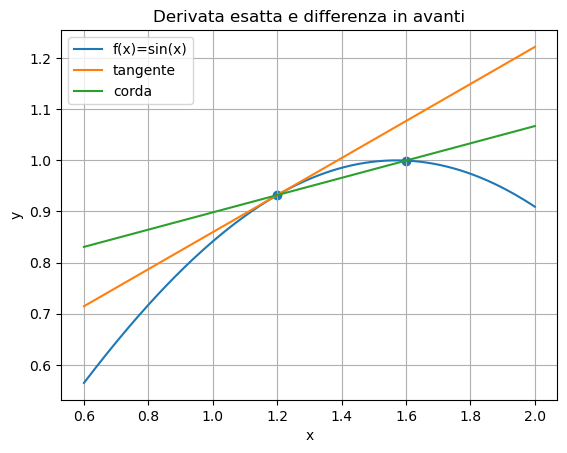

In [1481]:
# Interpretazione geometrica: tangente e corda.

x0 = 1.2
h = 0.4
f0 = math.sin(x0)
f1 = math.sin(x0 + h)
slope_chord = (f1 - f0) / h
slope_tangent = math.cos(x0)

xs = np.linspace(0.6, 2.0, 400)
ys = np.sin(xs)
tangent = f0 + slope_tangent * (xs - x0)
chord = f0 + slope_chord * (xs - x0)

plt.figure()
plt.plot(xs, ys, label="f(x)=sin(x)")
plt.plot(xs, tangent, label="tangente")
plt.plot(xs, chord, label="corda")
plt.scatter([x0, x0+h], [f0, f1])
plt.title("Derivata esatta e differenza in avanti")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.legend()
plt.show()

## 13. Il significato della notazione $O$ 

Scrivere

$$
e(h)=O(h^q)
$$

significa che esiste una costante $C>0$ tale che, per $h$ abbastanza piccolo,

$$
|e(h)|\le Ch^q.
$$


Per la differenza in avanti:

$$
e(h)=O(h).
$$

Per $f(x)=\sin(x)$ e $x_0=1.2$, il termine principale è circa

$$
\frac{h}{2}|f''(x_0)|
=
\frac{h}{2}|\sin(1.2)|.
$$

In [1482]:
x0 = 1.2
f0 = math.sin(x0)
fp = math.cos(x0)

hs = np.array([10.0**(-k) for k in range(1, 8)])
errs = np.abs(fp - (np.sin(x0 + hs) - f0)/hs)
estimate = 0.5 * abs(math.sin(x0)) * hs

print(f"{'h':>12} {'errore':>16} {'stima 0.5|sin(x0)|h':>24} {'errore/h':>16}")
for h, e, est in zip(hs, errs, estimate):
    print(f"{h:12.1e} {e:16.8e} {est:24.8e} {e/h:16.8e}")

           h           errore      stima 0.5|sin(x0)|h         errore/h
     1.0e-01   4.71667600e-02           4.66019543e-02   4.71667600e-01
     1.0e-02   4.66619586e-03           4.66019543e-03   4.66619586e-01
     1.0e-03   4.66079897e-04           4.66019543e-04   4.66079897e-01
     1.0e-04   4.66025576e-05           4.66019543e-05   4.66025576e-01
     1.0e-05   4.66019133e-06           4.66019543e-06   4.66019133e-01
     1.0e-06   4.65968587e-07           4.66019543e-07   4.65968587e-01
     1.0e-07   4.61932619e-08           4.66019543e-08   4.61932619e-01


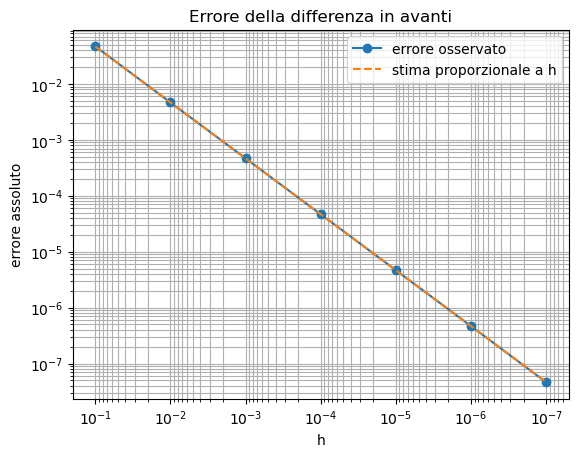

In [1483]:
plt.figure()
plt.loglog(hs, errs, marker="o", label="errore osservato")
plt.loglog(hs, estimate, linestyle="--", label="stima proporzionale a h")
plt.gca().invert_xaxis()
plt.title("Errore della differenza in avanti")
plt.xlabel("h")
plt.ylabel("errore assoluto")
plt.grid(True, which="both")
plt.legend()
plt.show()

<div style="
    padding: 18px 22px;
    margin: 16px 0;
    border-left: 5px solid #4a90e2;
    border-radius: 6px;
    background-color: rgba(74, 144, 226, 0.10);
">

<h3 style="margin-top: 0;">📈 Nota — Plot in scala bilogaritmica</h3>

Un **plot in scala bilogaritmica** (log–log) usa una scala logaritmica su entrambi gli assi. È utile soprattutto per:

- rappresentare dati che coprono molti ordini di grandezza;
- riconoscere una **legge di potenza** $y=Cx^n$, che nel grafico appare come una retta;
- ricavare l’esponente $n$, che coincide con la pendenza della retta.

#### Esempio: caduta libera

Per la caduta libera:

$$
s=\frac{g}{2}t^2
$$

Prendendo i logaritmi:

$$
\log s=\log\left(\frac{g}{2}\right)+2\log t
$$

Plottando $s$ rispetto a $t$ in scala bilogaritmica, si ottiene quindi una retta con **pendenza 2**. Questo permette di verificare sperimentalmente che lo spazio è proporzionale al quadrato del tempo.

#### Perché evidenzia le variazioni relative?

In una scala logaritmica, la distanza tra due valori dipende dal loro **rapporto**:

$$
\log(x_2)-\log(x_1)
=
\log\left(\frac{x_2}{x_1}\right)
$$

Intervalli con lo stesso fattore moltiplicativo hanno quindi la stessa lunghezza sul grafico. Per esempio, gli intervalli da $1$ a $10$ e da $10$ a $100$ sono uguali perché entrambi corrispondono a una moltiplicazione per $10$.

In breve:

scala lineare → distanze uguali indicano incrementi uguali;

scala logaritmica → distanze uguali indicano fattori moltiplicativi uguali.

Per questo la scala logaritmica mette in evidenza variazioni percentuali o relative: passare da $1$ a $2$ equivale a un aumento del (100%), proprio come passare da $10$ a $20$.

<hr style="border: 0; border-top: 1px solid rgba(74, 144, 226, 0.35);">

<strong>⚠️ Attenzione:</strong> normalmente una scala logaritmica non può rappresentare valori nulli o negativi.

</div>

# Parte VI — Quando $h$ diventa troppo piccolo

## 14. Effetto combinato di discretizzazione e arrotondamento

Dalla teoria sembrerebbe che, diminuendo $h$, l'errore della differenza in avanti debba diminuire sempre.

In realtà, per $h$ molto piccolo, la formula

$$
\frac{f(x_0+h)-f(x_0)}{h}
$$

sottrae due numeri quasi uguali.

Questa sottrazione amplifica gli errori di arrotondamento.

Inoltre, dopo aver calcolato questa differenza, dividiamo per $h$. Se $h$ è molto piccolo, la divisione per h può amplificare l'errore di arrotondamento già presente al numeratore.

Quindi l'errore totale ha due componenti:

$$
\text{errore totale}
=
\text{errore di discretizzazione}
+
\text{errore di arrotondamento}.
$$

Per $h$ grande domina la discretizzazione.  
Per $h$ molto piccolo domina l'arrotondamento.

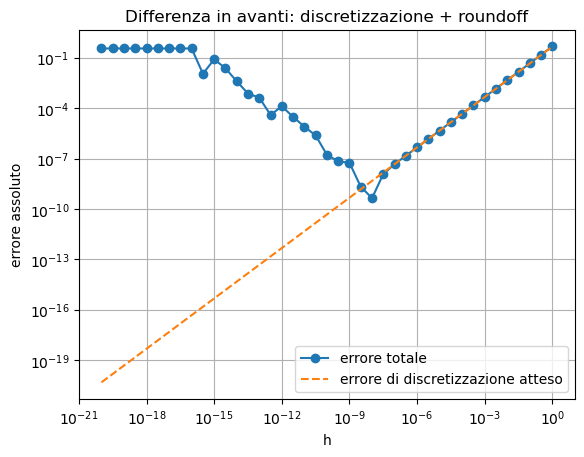

errore minimo osservato: 4.3610515199077327e-10
h del minimo osservato: 1e-08


In [1484]:
x0 = 1.2
f0 = math.sin(x0)
fp = math.cos(x0)

exponents = np.arange(-20, 0.5, 0.5)
h = 10.0 ** exponents
err = np.abs(fp - (np.sin(x0 + h) - f0)/h)
d_err = 0.5 * abs(math.sin(x0)) * h

idx_min = np.argmin(err)

plt.figure()
plt.loglog(h, err, marker="o", label="errore totale")
plt.loglog(h, d_err, linestyle="--", label="errore di discretizzazione atteso")
plt.title("Differenza in avanti: discretizzazione + roundoff")
plt.xlabel("h")
plt.ylabel("errore assoluto")
plt.grid(True, which="both")
plt.legend()
plt.show()

print("errore minimo osservato:", err[idx_min])
print("h del minimo osservato:", h[idx_min])

## 15. Lettura del grafico

Il grafico log-log mostra tre regioni:

1. per $h$ non troppo piccolo, l'errore decresce quasi linearmente con $h$;
2. intorno a un valore ottimale di $h$, l'errore raggiunge un minimo;
3. per $h$ molto piccolo, l'errore cresce o oscilla a causa dell'arrotondamento.

Questa è una lezione fondamentale:

> scegliere un passo più piccolo non garantisce sempre un risultato più accurato.

## 16. Differenza centrata

Una formula più accurata della differenza in avanti è la **differenza centrata**:

$$
f'(x_0)\approx
\frac{f(x_0+h)-f(x_0-h)}{2h}.
$$

L'idea è usare due valori della funzione, uno a destra e uno a sinistra di $x_0$, in modo simmetrico.

Scriviamo gli sviluppi di Taylor di $f(x_0+h)$ e $f(x_0-h)$ attorno a $x_0$:

$$
f(x_0+h)
=
f(x_0)
+
h f'(x_0)
+
\frac{h^2}{2}f''(x_0)
+
\frac{h^3}{6}f'''(x_0)
+
O(h^4),
$$

mentre

$$
f(x_0-h)
=
f(x_0)
-
h f'(x_0)
+
\frac{h^2}{2}f''(x_0)
-
\frac{h^3}{6}f'''(x_0)
+
O(h^4).
$$

Osserviamo che i termini con potenze pari di $h$, cioè $f(x_0)$ e $\frac{h^2}{2}f''(x_0)$, hanno lo stesso segno nei due sviluppi. I termini con potenze dispari, invece, cambiano segno.

Sottraendo il secondo sviluppo dal primo otteniamo

$$
f(x_0+h)-f(x_0-h)
=
2h f'(x_0)
+
\frac{2h^3}{6}f'''(x_0)
+
O(h^5).
$$

I termini pari si cancellano proprio perché stiamo usando una formula simmetrica rispetto a $x_0$.

Ora dividiamo per $2h$:

$$
\frac{f(x_0+h)-f(x_0-h)}{2h}
=
f'(x_0)
+
\frac{h^2}{6}f'''(x_0)
+
O(h^4).
$$

Quindi

$$
\frac{f(x_0+h)-f(x_0-h)}{2h}-f'(x_0)
=
\frac{h^2}{6}f'''(x_0)
+
O(h^4).
$$

Il termine principale dell'errore è proporzionale a $h^2$. Per questo motivo l'errore di discretizzazione è

$$
O(h^2).
$$

In altre parole, la differenza centrata è un metodo del **secondo ordine**: se dimezziamo $h$, l'errore di discretizzazione si riduce circa di un fattore $4$.

In [1485]:
def centered_difference(f, x0, h):
    return (f(x0 + h) - f(x0 - h)) / (2*h)

x0 = 1.2
true_derivative = math.cos(x0)

hs = 10.0 ** np.arange(-1, -9, -1)
err_forward = np.abs(true_derivative - np.array([forward_difference(math.sin, x0, hh) for hh in hs]))
err_centered = np.abs(true_derivative - np.array([centered_difference(math.sin, x0, hh) for hh in hs]))

print(f"{'h':>12} {'err forward':>18} {'err centered':>18}")
for hh, ef, ec in zip(hs, err_forward, err_centered):
    print(f"{hh:12.1e} {ef:18.8e} {ec:18.8e}")

           h        err forward       err centered
     1.0e-01     4.71667600e-02     6.03627698e-04
     1.0e-02     4.66619586e-03     6.03926571e-06
     1.0e-03     4.66079897e-04     6.03930144e-08
     1.0e-04     4.66025576e-05     6.03618711e-10
     1.0e-05     4.66019133e-06     2.43299825e-12
     1.0e-06     4.65968587e-07     7.98405786e-12
     1.0e-07     4.61932619e-08     1.19006360e-10
     1.0e-08     4.36105152e-10     4.36105152e-10


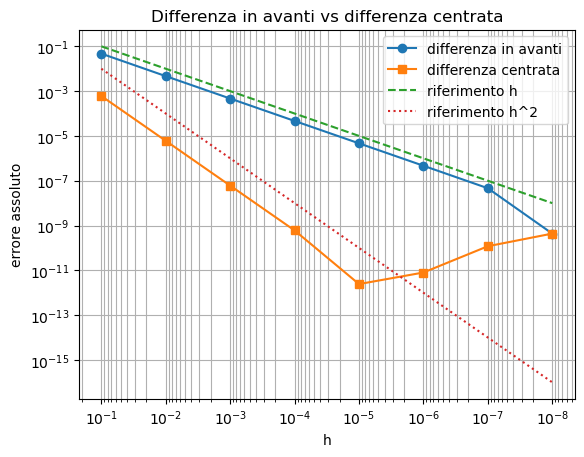

In [1486]:
plt.figure()
plt.loglog(hs, err_forward, marker="o", label="differenza in avanti")
plt.loglog(hs, err_centered, marker="s", label="differenza centrata")
plt.loglog(hs, hs, linestyle="--", label="riferimento h")
plt.loglog(hs, hs**2, linestyle=":", label="riferimento h^2")
plt.gca().invert_xaxis()
plt.title("Differenza in avanti vs differenza centrata")
plt.xlabel("h")
plt.ylabel("errore assoluto")
plt.grid(True, which="both")
plt.legend()
plt.show()

## Un ulteriore esempio

Ripetere l'esperimento precedente per

$$
f(x)=e^{-2x}
$$

nel punto

$$
x_0=0.5.
$$

Confrontare il grafico con quello ottenuto per $\sin(x)$.

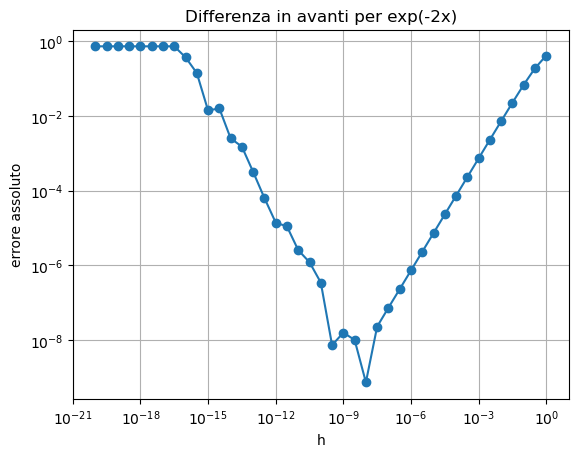

In [1487]:
# Spazio per gli studenti

def f_exp(x):
    return np.exp(-2*x)

def df_exp(x):
    return -2*np.exp(-2*x)

x0 = 0.5
true_derivative = df_exp(x0)

h = 10.0 ** np.arange(-20, 0.5, 0.5)
err = np.abs(true_derivative - (f_exp(x0 + h) - f_exp(x0))/h)

plt.figure()
plt.loglog(h, err, marker="o")
plt.title("Differenza in avanti per exp(-2x)")
plt.xlabel("h")
plt.ylabel("errore assoluto")
plt.grid(True, which="both")
plt.show()

# Parte VII — Proprietà degli algoritmi

## 17. Accuratezza

L'accuratezza misura quanto il risultato calcolato è vicino alla soluzione esatta.

Può essere valutata con:

- errore assoluto;
- errore relativo;
- residuo;
- stime teoriche.

---

Il **residuo** misura quanto bene il risultato calcolato soddisfa l'equazione o il problema di partenza.

Ad esempio, se vogliamo risolvere un'equazione

$$
f(x)=0
$$

e il metodo numerico produce un'approssimazione $\tilde{x}$, il residuo è

$$
r=f(\tilde{x}).
$$

Se $r$ è vicino a zero, significa che $\tilde{x}$ soddisfa quasi l'equazione.

Analogamente, per un sistema lineare

$$
Ax=b,
$$

se $\tilde{x}$ è la soluzione numerica calcolata, il residuo è

$$
r=b-A\tilde{x}.
$$

Un residuo piccolo indica che $A\tilde{x}$ è vicino a $b$, cioè che la soluzione calcolata soddisfa quasi il sistema.

È importante però distinguere tra **errore** e **residuo**:

- l'errore misura quanto $\tilde{x}$ è vicino alla soluzione esatta;
- il residuo misura quanto $\tilde{x}$ soddisfa bene l'equazione.

>In molti casi il residuo è utile perché la soluzione esatta non è nota, mentre il residuo può essere calcolato direttamente.

Un algoritmo numerico dovrebbe permettere di prevedere la grandezza dell'errore atteso.

## 18. Efficienza

L'efficienza riguarda il **costo computazionale**.

Si può misurare con:

- numero di operazioni aritmetiche;
- tempo CPU;
- memoria richiesta;
- accessi alla memoria;
- possibilità di vettorizzazione o parallelizzazione.

Una stima classica conta le operazioni elementari, spesso chiamate **flops**.

## 19. Robustezza

La robustezza misura la capacità di un algoritmo di funzionare bene in situazioni diverse.

Un algoritmo robusto dovrebbe:

- produrre un risultato entro una tolleranza accettabile;
- oppure segnalare chiaramente il fallimento;
- evitare risultati apparentemente validi ma numericamente privi di senso.

Molto software numerico è complesso perché deve gestire casi limite, non perché l'idea matematica di base sia difficile.

# Parte VIII — Efficienza: la regola di Horner

## 20. Valutazione di un polinomio

Consideriamo un polinomio di grado $n$:

$$
p_n(x)=c_0+c_1x+\cdots+c_nx^n.
$$

Una valutazione ingenua può richiedere molte operazioni, soprattutto se ogni potenza $x^k$ viene calcolata separatamente.

Per ottenere la **forma di Horner**, raccogliamo progressivamente il fattore $x$. Iniziamo scrivendo:

$$
p_n(x)
=
c_0+x\left(c_1+c_2x+\cdots+c_nx^{n-1}\right).
$$

All’interno delle parentesi possiamo raccogliere nuovamente $x$:

$$
p_n(x)
=
c_0+x\left[c_1+x\left(c_2+c_3x+\cdots+c_nx^{n-2}\right)\right].
$$

Ripetendo lo stesso procedimento si ottiene:

$$
p_n(x)
=
c_0+x\left(c_1+x\left(c_2+\cdots+x\left(c_{n-1}+xc_n\right)\right)\right).
$$

Scrivendo le operazioni nell’ordine in cui vengono eseguite, la stessa espressione assume la forma usuale della **regola di Horner**:

$$
p_n(x)
=
(\cdots((c_nx+c_{n-1})x+c_{n-2})x+\cdots)x+c_0.
$$

Per esempio, nel caso di un polinomio di terzo grado:

$$
\begin{aligned}
p_3(x)
&=c_0+c_1x+c_2x^2+c_3x^3\\
&=c_0+x(c_1+c_2x+c_3x^2)\\
&=c_0+x\left[c_1+x(c_2+c_3x)\right]\\
&=((c_3x+c_2)x+c_1)x+c_0.
\end{aligned}
$$

L’algoritmo può essere descritto anche in forma ricorsiva:

$$
b_n=c_n,
\qquad
b_k=c_k+xb_{k+1},
\quad k=n-1,n-2,\ldots,0,
$$

e alla fine:

$$
p_n(x)=b_0.
$$

A ogni passaggio vengono eseguite una moltiplicazione e un’addizione. In totale servono quindi solo $n$ moltiplicazioni e $n$ addizioni, con costo computazionale $O(n)$.

In [1488]:
def poly_naive(c, x):
    total = 0.0
    ops = 0
    n = len(c) - 1
    for k in range(n + 1):
        power = 1.0
        for _ in range(k):
            power *= x
            ops += 1
        total += c[k] * power
        ops += 1
        if k > 0:
            ops += 1
    return total, ops

def poly_horner(c, x):
    p = c[-1]
    ops = 0
    for j in range(len(c)-2, -1, -1):
        p = p * x + c[j]
        ops += 2
    return p, ops

c = np.array([1.0, -3.0, 2.0, 5.0, -1.0])
x = 1.7

p1, o1 = poly_naive(c, x)
p2, o2 = poly_horner(c, x)

print("valore ingenuo:", p1, "operazioni stimate:", o1)
print("valore Horner :", p2, "operazioni stimate:", o2)
print("differenza:", abs(p1-p2))

valore ingenuo: 17.892899999999997 operazioni stimate: 19
valore Horner : 17.892899999999997 operazioni stimate: 8
differenza: 0.0


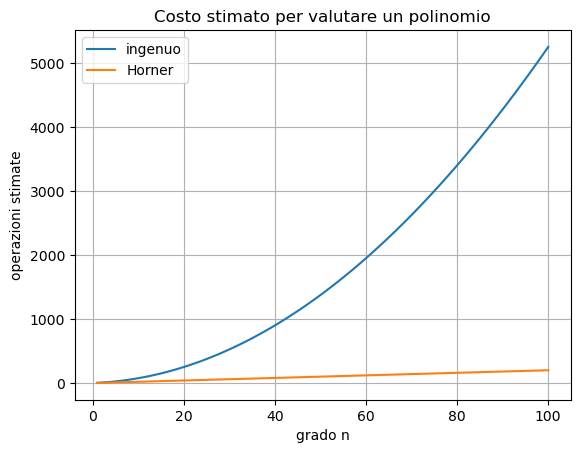

In [1489]:
degrees = np.arange(1, 101)
ops_naive = []
ops_horner = []

for n in degrees:
    c = np.ones(n+1)
    _, on = poly_naive(c, 1.1)
    _, oh = poly_horner(c, 1.1)
    ops_naive.append(on)
    ops_horner.append(oh)

plt.figure()
plt.plot(degrees, ops_naive, label="ingenuo")
plt.plot(degrees, ops_horner, label="Horner")
plt.title("Costo stimato per valutare un polinomio")
plt.xlabel("grado n")
plt.ylabel("operazioni stimate")
plt.grid(True)
plt.legend()
plt.show()

# Parte IX — Condizionamento e stabilità

## 21. Condizionamento del problema

Il condizionamento è una proprietà del problema matematico.

Un problema è **ben condizionato** se piccole perturbazioni nei dati producono piccole perturbazioni nel risultato.

Un problema è **mal condizionato** se piccole perturbazioni nei dati possono produrre grandi variazioni nel risultato.

In forma intuitiva, consideriamo un problema descritto da una funzione

$$
y=g(x),
$$

dove $x$ rappresenta il dato in ingresso e $y$ il risultato.

Se perturbiamo leggermente il dato, passando da $x$ a $x+\Delta x$, anche il risultato cambia:

$$
g(x+\Delta x)-g(x).
$$

Il problema è **sensibile vicino a $x$** quando questa variazione del risultato è grande rispetto alla perturbazione introdotta nel dato.

In altre parole, anche se

$$
|\Delta x|
$$

è piccolo, può succedere che

$$
|g(x+\Delta x)-g(x)|
$$

sia molto più grande.

### Esempio

Consideriamo la funzione

$$
g(x)=\frac{1}{1-x}.
$$

In prossimità di $x=1$, il denominatore è molto piccolo e la funzione diventa particolarmente sensibile alle variazioni del dato.

Partiamo da

$$
x=0.99,
$$

per il quale otteniamo

$$
g(0.99)=\frac{1}{1-0.99}=100.
$$

Introduciamo ora una piccola perturbazione:

$$
\Delta x=0.0001.
$$

Il nuovo dato è $x+\Delta x=0.9901$ e il risultato diventa

$$
g(0.9901)
=
\frac{1}{1-0.9901}
\approx 101.01.
$$

Sebbene il dato sia cambiato soltanto di $0.0001$, il risultato è cambiato di circa

$$
|g(0.9901)-g(0.99)|\approx 1.01.
$$

La variazione assoluta del risultato è quindi circa diecimila volte più grande della perturbazione introdotta:

$$
\frac{1.01}{0.0001}\approx 10\,100.
$$

Questo accade perché, quando $x$ è vicino a $1$, una piccola variazione di $x$ produce una variazione relativamente grande nel denominatore $1-x$ e, di conseguenza, nel valore della funzione.

Il problema amplifica quindi gli errori presenti nei dati iniziali. In una situazione di questo tipo non possiamo aspettarci un risultato molto accurato, anche usando un algoritmo numerico ben progettato.

## 22. Stabilità dell'algoritmo

La stabilità è una proprietà dell'algoritmo numerico.

Mentre il **condizionamento** riguarda il problema matematico, la **stabilità** riguarda il modo in cui l'algoritmo esegue i calcoli.

Un algoritmo è **stabile** se non amplifica troppo gli errori che si generano durante il calcolo, ad esempio gli errori di arrotondamento.

Un algoritmo è **instabile** se piccoli errori introdotti nei passaggi intermedi possono crescere molto e compromettere il risultato finale.

In forma intuitiva, immaginiamo che un algoritmo esegua una sequenza di operazioni:

$$
x_0 \longrightarrow x_1 \longrightarrow x_2 \longrightarrow \cdots \longrightarrow x_N.
$$

In aritmetica esatta, cioè senza errori di arrotondamento, otterremmo una certa sequenza di valori. In un computer, invece, ogni operazione può introdurre un piccolo errore. Quindi, invece di calcolare esattamente $x_1$, $x_2$, ..., $x_N$, il computer calcola valori leggermente perturbati:

$$
\tilde{x}_1,\tilde{x}_2,\ldots,\tilde{x}_N.
$$

Il punto cruciale è capire che cosa succede a questi piccoli errori mentre l'algoritmo procede.

Se gli errori restano piccoli, o comunque non vengono amplificati in modo significativo, l'algoritmo è stabile.

Se invece gli errori crescono passo dopo passo, l'algoritmo è instabile.

In altre parole, un algoritmo stabile si comporta bene anche quando i calcoli non sono esatti, mentre un algoritmo instabile può produrre risultati poco affidabili anche partendo da dati corretti.

<div style="
    padding: 18px 22px;
    margin: 16px 0;
    border-left: 5px solid #e09f3e;
    border-radius: 6px;
    background-color: rgba(224, 159, 62, 0.10);
">

<h3 style="margin-top: 0;">💡 Nota — Differenza tra condizionamento e stabilità</h3>

<p>È importante distinguere i due concetti:</p>

<ul>
    <li>
        il <strong>condizionamento</strong> indica quanto il problema matematico è sensibile a piccole perturbazioni nei dati;
    </li>
    <li>
        la <strong>stabilità</strong> indica quanto l’algoritmo è sensibile ai piccoli errori prodotti durante il calcolo.
    </li>
</ul>

<p>Di conseguenza:</p>

<ul>
    <li>un problema mal condizionato è difficile per qualunque algoritmo;</li>
    <li>un algoritmo instabile può dare cattivi risultati anche per un problema ben condizionato;</li>
    <li>un buon algoritmo dovrebbe evitare di amplificare inutilmente gli errori di arrotondamento.</li>
</ul>

<hr style="border: 0; border-top: 1px solid rgba(224, 159, 62, 0.40);">

<p style="margin-bottom: 0;">
    <strong>In sintesi:</strong> il condizionamento riguarda il
    <strong>problema</strong>, mentre la stabilità riguarda il
    <strong>metodo usato per risolverlo</strong>.
</p>

</div>

## 23. Esempio ben condizionato: $\sqrt{1+x}$ vicino a zero

Consideriamo la funzione

$$
g(x)=\sqrt{1+x}.
$$

Per capire come una piccola perturbazione del dato si trasmette al risultato, sostituiamo $x$ con $x+\Delta x$. La variazione dell’output è

$$
\Delta y
=
g(x+\Delta x)-g(x).
$$

Se $g$ è derivabile e $\Delta x$ è piccolo, possiamo usare l’approssimazione lineare:

$$
g(x+\Delta x)
\approx
g(x)+g'(x)\Delta x.
$$

Sottraendo $g(x)$ da entrambi i membri, otteniamo

$$
\Delta y
\approx
g'(x)\Delta x.
$$

La derivata $g'(x)$ descrive quindi il **fattore di amplificazione locale** delle piccole perturbazioni:

- se $|g'(x)|$ è piccolo, la perturbazione viene attenuata;
- se $|g'(x)|\approx 1$, la perturbazione rimane dello stesso ordine;
- se $|g'(x)|$ è grande, la perturbazione viene amplificata.

Nel nostro caso,

$$
g'(x)=\frac{1}{2\sqrt{1+x}},
$$

e quindi

$$
g'(0)=\frac{1}{2}.
$$

Pertanto, vicino a $x=0$,

$$
\Delta y
\approx
\frac{1}{2}\Delta x.
$$

Una piccola perturbazione del dato in ingresso viene quindi circa dimezzata nell’output. Per esempio, ponendo $x=0$ e introducendo una piccola perturbazione $\Delta x$, si ha

$$
g(\Delta x)=\sqrt{1+\Delta x}
\approx
1+\frac{\Delta x}{2}.
$$

Poiché la funzione non amplifica le piccole perturbazioni vicino a zero, il problema è, in senso assoluto, **ben condizionato** in questa regione.

In [1490]:
for x in [1e-1, 1e-2, 1e-3, 1e-4]:
    dy = math.sqrt(1+x) - 1
    print(f"x={x:.1e}, sqrt(1+x)-1={dy:.6e}, rapporto={dy/x:.6f}")

x=1.0e-01, sqrt(1+x)-1=4.880885e-02, rapporto=0.488088
x=1.0e-02, sqrt(1+x)-1=4.987562e-03, rapporto=0.498756
x=1.0e-03, sqrt(1+x)-1=4.998751e-04, rapporto=0.499875
x=1.0e-04, sqrt(1+x)-1=4.999875e-05, rapporto=0.499988


## 24. Esempio mal condizionato: $\tan(x)$ vicino a $\pi/2$

Consideriamo

$$
g(x)=\tan(x).
$$

La derivata è

$$
g'(x)=\frac{1}{\cos^2(x)}.
$$

Quando $x$ è vicino a $\pi/2$, $\cos(x)$ è vicino a zero e la derivata diventa molto grande.

Quindi valutare $\tan(x)$ vicino a $\pi/2$ è un problema mal condizionato.

In [1491]:
x = math.pi/2 - 0.001
xbar = math.pi/2 - 0.002

input_diff = abs(x - xbar)
output_diff = abs(math.tan(x) - math.tan(xbar))

print("|x - xbar| =", input_diff)
print("|tan(x) - tan(xbar)| =", output_diff)
print("fattore di amplificazione =", output_diff / input_diff)

|x - xbar| = 0.001000000000000112
|tan(x) - tan(xbar)| = 500.0003333335536
fattore di amplificazione = 500000.33333349763


## 25. Accumulo degli errori

Gli errori di arrotondamento si accumulano durante un calcolo.

Indichiamo con $E_0$ l'errore iniziale, cioè l'errore presente all'inizio del processo di calcolo o introdotto in un singolo passo.

Indichiamo invece con $E_n$ l'errore dopo $n$ passi dell'algoritmo.

Una crescita lineare è spesso inevitabile e tollerabile:

$$
E_n\le c_0 n E_0.
$$

Una crescita esponenziale è invece inaccettabile:

$$
E_n\le c_1^n E_0,
\qquad
c_1>1.
$$

Un algoritmo con crescita esponenziale dell'errore è instabile.

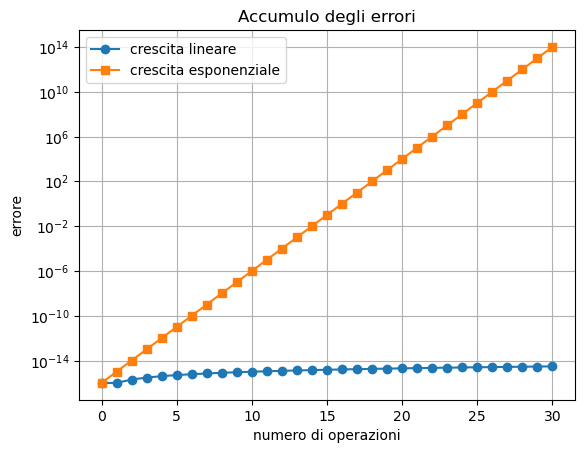

In [1492]:
n = np.arange(0, 31)
E0 = 1e-16

linear = E0 * np.maximum(n, 1)
exponential = E0 * (10.0 ** n)

plt.figure()
plt.semilogy(n, linear, marker="o", label="crescita lineare")
plt.semilogy(n, exponential, marker="s", label="crescita esponenziale")
plt.title("Accumulo degli errori")
plt.xlabel("numero di operazioni")
plt.ylabel("errore")
plt.grid(True)
plt.legend()
plt.show()

## 26. Esempio instabile: ricorrenza per integrali

Consideriamo

$$
y_n=\int_0^1 \frac{x^n}{x+10}\,dx.
$$

Si verifica che

$$
y_n+10y_{n-1}=\frac{1}{n}.
$$

Quindi una ricorrenza naturale è

$$
y_n=\frac{1}{n}-10y_{n-1}.
$$

Il valore iniziale si calcola esplicitamente:

$$
y_0=\int_{10}^{11}\frac{1}{x}\,dx
=
\left[\ln x\right]_{10}^{11}
=
\ln(11)-\ln(10)
=
\ln\left(\frac{11}{10}\right).
$$

Questa ricorrenza è instabile: ogni errore viene moltiplicato circa per 10.

---

### Spiegazione dettagliata

Consideriamo la ricorrenza

$$
y_n=\frac{1}{n}-10y_{n-1}.
$$

Supponiamo che il valore esatto al passo $n-1$ sia $y_{n-1}$, ma che il computer abbia calcolato un valore leggermente perturbato

$$
\tilde{y}_{n-1}=y_{n-1}+e_{n-1},
$$

dove $e_{n-1}$ è l'errore al passo $n-1$.

Applicando la ricorrenza al valore calcolato, otteniamo

$$
\tilde{y}_n
=
\frac{1}{n}-10\tilde{y}_{n-1}.
$$

Sostituendo $\tilde{y}_{n-1}=y_{n-1}+e_{n-1}$:

$$
\tilde{y}_n
=
\frac{1}{n}-10(y_{n-1}+e_{n-1})
=
\frac{1}{n}-10y_{n-1}-10e_{n-1}.
$$

Il valore esatto soddisfa invece

$$
y_n=\frac{1}{n}-10y_{n-1}.
$$

Quindi l'errore al passo $n$ è

$$
e_n
=
\tilde{y}_n-y_n.
$$

Sostituendo le due espressioni:

$$
e_n
=
\left(\frac{1}{n}-10y_{n-1}-10e_{n-1}\right)
-
\left(\frac{1}{n}-10y_{n-1}\right)
=
-10e_{n-1}.
$$

Di conseguenza,

$$
|e_n|=10|e_{n-1}|.
$$

Questo significa che, a ogni passo, l'errore viene moltiplicato per circa $10$. Dopo pochi passi, anche un errore inizialmente molto piccolo può diventare grande.

Per questo motivo la ricorrenza

$$
y_n=\frac{1}{n}-10y_{n-1}
$$

è **instabile**.

In [1493]:
def unstable_integral_recursion(N):
    y = np.zeros(N+1)
    y[0] = math.log(11) - math.log(10)
    for n in range(1, N+1):
        y[n] = 1/n - 10*y[n-1]
    return y

y_unstable = unstable_integral_recursion(30)

for n in range(0, 31):
    print(f"n={n:2d}, y_n={y_unstable[n]: .6e}")

n= 0, y_n= 9.531018e-02
n= 1, y_n= 4.689820e-02
n= 2, y_n= 3.101798e-02
n= 3, y_n= 2.315353e-02
n= 4, y_n= 1.846471e-02
n= 5, y_n= 1.535290e-02
n= 6, y_n= 1.313766e-02
n= 7, y_n= 1.148056e-02
n= 8, y_n= 1.019438e-02
n= 9, y_n= 9.167295e-03
n=10, y_n= 8.327049e-03
n=11, y_n= 7.638606e-03
n=12, y_n= 6.947277e-03
n=13, y_n= 7.450304e-03
n=14, y_n=-3.074466e-03
n=15, y_n= 9.741133e-02
n=16, y_n=-9.116133e-01
n=17, y_n= 9.174957e+00
n=18, y_n=-9.169401e+01
n=19, y_n= 9.169927e+02
n=20, y_n=-9.169877e+03
n=21, y_n= 9.169882e+04
n=22, y_n=-9.169882e+05
n=23, y_n= 9.169882e+06
n=24, y_n=-9.169882e+07
n=25, y_n= 9.169882e+08
n=26, y_n=-9.169882e+09
n=27, y_n= 9.169882e+10
n=28, y_n=-9.169882e+11
n=29, y_n= 9.169882e+12
n=30, y_n=-9.169882e+13


## 27. Ricorrenza stabile all'indietro

Dalla stessa relazione

$$
y_n+10y_{n-1}=\frac{1}{n}
$$

otteniamo

$$
y_{n-1}=\frac{1}{10}\left(\frac{1}{n}-y_n\right).
$$

Usata all'indietro, questa formula divide l'errore per 10 a ogni passo.

Se partiamo da un indice grande $N$ ponendo approssimativamente $y_N=0$, possiamo calcolare valori accurati per indici più piccoli.

In [1494]:
def stable_backward_integral(N):
    y = np.zeros(N+1)
    y[N] = 0.0
    for n in range(N, 0, -1):
        y[n-1] = (1/n - y[n]) / 10
    return y

N = 80
y_stable = stable_backward_integral(N)

print(f"{'n':>3} {'instabile':>18} {'stabile':>18}")
for n in range(0, 21):
    print(f"{n:3d} {y_unstable[n]:18.8e} {y_stable[n]:18.8e}")

print("\ny0 esatto =", math.log(11) - math.log(10))
print("y0 stabile =", y_stable[0])

  n          instabile            stabile
  0     9.53101798e-02     9.53101798e-02
  1     4.68982020e-02     4.68982020e-02
  2     3.10179804e-02     3.10179804e-02
  3     2.31535290e-02     2.31535290e-02
  4     1.84647099e-02     1.84647099e-02
  5     1.53529009e-02     1.53529008e-02
  6     1.31376581e-02     1.31376582e-02
  7     1.14805618e-02     1.14805609e-02
  8     1.01943816e-02     1.01943908e-02
  9     9.16729515e-03     9.16720345e-03
 10     8.32704853e-03     8.32796552e-03
 11     7.63860560e-03     7.62943572e-03
 12     6.94727731e-03     7.03897613e-03
 13     7.45030378e-03     6.53331561e-03
 14    -3.07446639e-03     6.09541530e-03
 15     9.74113306e-02     5.71251363e-03
 16    -9.11613306e-01     5.37486367e-03
 17     9.17495659e+00     5.07489273e-03
 18    -9.16940103e+01     4.80662825e-03
 19     9.16992735e+02     4.56529642e-03
 20    -9.16987735e+03     4.34703582e-03

y0 esatto = 0.09531017980432477
y0 stabile = 0.09531017980432485


# Riepilogo finale

## Checklist dei concetti principali

Al termine della lezione dovreste saper spiegare:

1. la differenza fra calcolo scientifico e analisi numerica;
2. errore assoluto e relativo;
3. errori nel problema, di discretizzazione, di convergenza e di arrotondamento;
4. perché la differenza in avanti ha errore $O(h)$;
5. perché la differenza centrata ha errore $O(h^2)$;
6. perché l'errore può aumentare quando $h$ è troppo piccolo;
7. accuratezza, efficienza e robustezza;
8. differenza fra condizionamento e stabilità;
9. cosa significa crescita lineare o esponenziale degli errori;
10. come funziona una rappresentazione floating-point;
11. cosa misura l'unità di arrotondamento;
12. cosa sono overflow, underflow e NaN;
13. perché la cancellazione è pericolosa;
14. come riscrivere formule per renderle più stabili;
15. perché i confronti floating-point devono usare tolleranze.

## Glossario

**Errore assoluto:** $|u-v|$.

**Errore relativo:** $|u-v|/|u|$.

**Errore di discretizzazione:** errore dovuto alla sostituzione di un problema continuo con uno discreto.

**Errore di convergenza:** errore dovuto all'arresto di un metodo iterativo.

**Errore di arrotondamento:** errore dovuto alla rappresentazione finita dei numeri.

**Accuratezza:** vicinanza del risultato alla soluzione esatta.

**Efficienza:** costo computazionale di un algoritmo.

**Robustezza:** capacità di un algoritmo di funzionare in modo affidabile.

**Condizionamento:** sensibilità del problema alle perturbazioni dei dati.

**Stabilità:** capacità dell'algoritmo di non amplificare eccessivamente gli errori.

**Floating-point:** rappresentazione a virgola mobile.

**Mantissa:** parte significativa del numero floating-point.

**Esponente:** parte che determina l'ordine di grandezza.

**Unità di arrotondamento:** limite superiore tipico dell'errore relativo di rappresentazione.

**Cancellazione:** perdita di cifre significative nella sottrazione di numeri quasi uguali.

**Overflow:** risultato troppo grande per essere rappresentato.

**Underflow:** risultato troppo piccolo per essere rappresentato come normalizzato.

**NaN:** Not a Number.

**Horner:** metodo efficiente per valutare polinomi.

**FMA:** fused multiply-add, operazione $fl(xy+z)$ con un solo arrotondamento.